# Домашнее задание к семинару 14 (HW14)

Тема: эмбеддинги, индекс `FAISS`, оценка качества retrieval, обновление базы знаний и базовый mini-RAG.

HW14 выполняется в личном репозитории студента (на основе шаблона курса) в папке `homeworks/HW14/`.

---

## 1. Цель

Закрепить:

- построение векторных представлений текстовых фрагментов;
- работу с индексом `FAISS` для поиска по базе знаний;
- базовую оценку качества извлечения (`retrieval`);
- обновление базы знаний и переиндексацию;
- сборку простого mini-RAG-контура;
- аккуратное оформление результата: один ноутбук, короткий отчёт, минимальные артефакты.

---

## 2. Задание

### 2.1. Структура для HW14 (обязательно)

1. В корне репозитория должна быть папка `homeworks/` (создать, если её ещё нет).
2. Внутри `homeworks/` создать папку `HW14/`.
3. В папке `homeworks/HW14/` создать:

- основной ноутбук: `HW14.ipynb`
- отчёт: `report.md`
- папку для артефактов: `artifacts/`

> Имена папок и файлов должны быть строго такими, как указано (регистр важен).

---

### 2.2. База знаний для домашней работы

Нужно выбрать **одну** небольшую текстовую базу знаний.

Подходящие варианты:

- подборка коротких тематических статей;
- FAQ или справочные материалы;
- набор внутренних регламентов / инструкций / заметок;
- markdown / txt / csv / json с текстовыми описаниями;
- любой другой **готовый** набор документов, если он подходит для retrieval-задачи.

Рекомендуемый масштаб:

- **10-30 документов**;
- или такой объём, который после чанкинга даёт примерно **30-150 текстовых фрагментов**.

Требования к базе знаний:

- документы должны относиться к одной понятной теме;
- документы должны быть достаточно содержательными, чтобы по ним имело смысл задавать вопросы;
- база знаний не должна быть слишком большой для обычного учебного запуска;
- база знаний должна быть загружена и обработана воспроизводимо.

Важно:

- **не требуется** искать большой промышленный датасет;
- **не требуется** поднимать внешнюю векторную БД;
- главное – корректно пройти учебный pipeline: чанки → эмбеддинги → индекс → retrieval → оценка → обновление → mini-RAG.

---

### 2.3. Содержание ноутбука `HW14.ipynb` (обязательно)

В ноутбуке `homeworks/HW14/HW14.ipynb` реализуйте и покажите следующие блоки.

#### 2.3.1. Импорты, seed и среда

Нужно:

1. Импортировать библиотеки: `numpy`, `pandas`, `sklearn`, `matplotlib`, `faiss` (или `faiss-cpu`) и всё, что нужно по делу.
2. Зафиксировать seed (минимум `random`, `numpy`; если используете `torch`, то и `torch`).
3. Если используется модель эмбеддингов на `torch`, определить устройство (`cuda` при наличии, иначе `cpu`) и использовать его последовательно.

In [290]:
# 2.3.1 Imports, seed and environment

import importlib, re
import subprocess
import sys, os
import random
from dataclasses import dataclass
from pathlib import Path
import torch 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from typing import List, Dict, Tuple, Optional
from IPython.display import display, Markdown

os.environ["TOKENIZERS_PARALLELISM"] = "false"

def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    """Пытается импортировать пакет и при необходимости установить его через pip."""
    target = import_name or package_name
    try:
        __import__(target)
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

# Для retrieval-контура попробуем установить основные зависимости.
# Даже если sentence-transformers не поднимется, ноутбук сможет работать через fallback.
ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")

try:
    import faiss  # type: ignore
    FAISS_AVAILABLE = True
except Exception as e:
    FAISS_AVAILABLE = False
    print("Не удалось импортировать faiss:", repr(e))

# Фиксируем seed и определяем устройство.
SEED = 42
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
set_seed(SEED)

try:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("NumPy:", np.__version__) 
print("Pandas:", pd.__version__) 
print("FAISS available:", FAISS_AVAILABLE) 
print("Устройство для работы:", DEVICE)

NumPy: 2.4.2
Pandas: 3.0.1
FAISS available: True
Устройство для работы: cpu


#### 2.3.2. База знаний и первичный анализ

Нужно:

- загрузить выбранную базу знаний;
- показать число документов;
- вывести 3-5 примеров документов или их фрагментов;
- кратко пояснить, что это за предметная область и почему по ней разумно строить retrieval / mini-RAG.

In [291]:
# 2.3.2. База знаний и первичный анализ

documents = [
    {
        "doc_id": "cat_001",
        "title": "Происхождение домашней кошки",
        "text": """Домашняя кошка относится к виду Felis catus. Считается, что предком домашней кошки была
ближневосточная дикая кошка Felis silvestris lybica. Одомашнивание кошек происходило постепенно,
когда животные начали жить рядом с человеческими поселениями, где было много зерна и грызунов.
Люди не приручали кошек так же активно, как собак, поэтому домашние кошки сохранили много черт
самостоятельного хищника. Генетические исследования показывают, что современная домашняя кошка
сохраняет близкое родство с дикими предками. Именно поэтому кошки даже в домашних условиях
демонстрируют охотничье поведение, территориальность и выраженный интерес к движущимся объектам.
Изучение происхождения кошек важно для понимания их поведения и адаптации к жизни рядом с человеком."""
    },
    {
        "doc_id": "cat_002",
        "title": "Особенности скелета и гибкости кошки",
        "text": """Кошки известны своей гибкостью и способностью быстро менять положение тела. Это связано
с особенностями строения их позвоночника, суставов и плечевого пояса. У кошки очень подвижный
позвоночник, который позволяет ей сгибаться и разворачиваться во время прыжков и падений.
Ключицы у кошек развиты иначе, чем у человека, поэтому передние конечности двигаются свободнее.
Благодаря этому кошка может пролезать в узкие пространства, если туда проходит её голова.
Гибкость тела помогает кошке во время охоты, лазания и прыжков. Однако гибкость не означает
полную неуязвимость: при неудачных падениях и травмах кошки тоже могут получать повреждения.
С точки зрения биомеханики кошка является очень эффективным мелким хищником."""
    },
    {
        "doc_id": "cat_003",
        "title": "Почему кошки хорошо видят в сумерках",
        "text": """Зрение кошек приспособлено к активности при слабом освещении. В сетчатке кошки много
палочек — клеток, которые хорошо работают в сумерках. Кроме того, у кошек есть отражающий слой
tapetum lucidum, который усиливает использование света и помогает видеть при низкой освещённости.
Именно из-за этого глаза кошек могут ярко светиться в темноте при попадании света. При этом
кошки различают цвета хуже человека и видят мир менее насыщенным по оттенкам. Их зрение лучше
подходит для обнаружения движения, чем для распознавания мелких неподвижных деталей. Такая
особенность полезна для охоты на мелкую добычу. С точки зрения эволюции это связано с образом
жизни сумеречного хищника, который наиболее активен утром и вечером."""
    },
    {
        "doc_id": "cat_004",
        "title": "Слух кошек и ориентация на звук",
        "text": """Слух у кошек очень чувствительный и играет важную роль в охоте и ориентировании в пространстве.
Кошки способны улавливать высокочастотные звуки, в том числе писк мелких грызунов. Их ушные раковины
могут поворачиваться независимо, что помогает точнее определять направление источника звука.
Благодаря этому кошка может быстро понять, откуда идёт шум, даже если объект скрыт от глаз.
Слух особенно важен в условиях слабого освещения, когда зрение работает не идеально. Комбинация
чувствительного слуха и хорошего зрения в сумерках делает кошку эффективным охотником. Исследования
поведения показывают, что кошки быстро реагируют на резкие и необычные звуки, но могут игнорировать
знакомые и безопасные бытовые шумы."""
    },
    {
        "doc_id": "cat_005",
        "title": "Вибриссы и пространственная ориентация",
        "text": """Вибриссы, которые часто называют усами, являются важным сенсорным инструментом кошки.
Они расположены не только на морде, но и над глазами, на подбородке и на передних лапах.
Вибриссы помогают кошке оценивать расстояние до объектов, чувствовать движение воздуха и
лучше ориентироваться в темноте. Они особенно полезны в узких пространствах и при исследовании
окружения. Вибриссы нельзя рассматривать как обычную шерсть, потому что они связаны с чувствительными
нервными структурами. Повреждение или сильное укорочение вибрисс может ухудшить ориентацию животного.
С научной точки зрения вибриссы — это важная часть сенсорной системы, которая дополняет зрение,
слух и осязание."""
    },
    {
        "doc_id": "cat_006",
        "title": "Почему кошки мурлыкают",
        "text": """Мурлыканье — одно из самых известных проявлений поведения кошек. Оно связано с ритмической
работой мышц гортани и дыхательной системы. Кошки могут мурлыкать в разных ситуациях: при комфорте,
при общении с человеком, во время кормления котят и иногда даже в стрессовых условиях. Поэтому
мурлыканье не всегда означает только удовольствие. Исследователи предполагают, что мурлыканье может
играть роль в коммуникации и самоуспокоении. Некоторые работы также обсуждают возможную связь между
вибрациями при мурлыканье и восстановительными процессами тканей, но этот вопрос изучен не полностью.
С поведенческой точки зрения мурлыканье важно анализировать в контексте всей ситуации, а не как
однозначный признак хорошего настроения."""
    },
    {
        "doc_id": "cat_007",
        "title": "Сон кошек и распределение активности",
        "text": """Кошки спят значительную часть суток, но это не значит, что они ленивы в биологическом смысле.
Многие кошки распределяют активность неравномерно и наиболее оживлены утром и вечером. Такой режим
часто называют сумеречной активностью. Большое количество сна помогает экономить энергию между
периодами активности и охоты. При этом часть времени кошка находится не в глубоком сне, а в лёгкой
дремоте, когда она сохраняет готовность быстро отреагировать на звук или движение. Продолжительность
сна может зависеть от возраста, уровня активности, окружающей среды и состояния животного. Наблюдение
за режимом сна полезно для понимания нормального поведения кошки в домашних условиях."""
    },
    {
        "doc_id": "cat_008",
        "title": "Территориальность и маркировка у кошек",
        "text": """Кошки являются территориальными животными. Они используют пространство не хаотично, а делят
его на значимые зоны: место отдыха, путь передвижения, точки наблюдения и участки с ресурсами.
Для обозначения территории кошки могут применять запаховые метки, трение мордой о предметы,
царапанье поверхностей и другие формы маркировки. Такое поведение связано не только с агрессией,
но и с созданием понятной и предсказуемой среды. В многокошачьих домах территориальные конфликты
могут усиливаться, если животным не хватает пространства и ресурсов. Изучение территориальности
важно для понимания стресса, поведения и организации среды для домашних кошек."""
    },
    {
        "doc_id": "cat_009",
        "title": "Питание кошек как облигатных хищников",
        "text": """Кошки относятся к облигатным хищникам. Это означает, что их организм эволюционно приспособлен
к рациону с высоким содержанием животного белка. У кошек есть особые потребности в некоторых веществах,
которые в природе они получают из тканей добычи. Например, для них особенно важны определённые
аминокислоты и соединения, связанные с животным происхождением пищи. Пищеварительная система кошки
лучше приспособлена к перевариванию мясных продуктов, чем к переработке большого количества
растительной пищи. С точки зрения биологии это объясняет, почему питание кошек отличается от питания
всеядных животных. Пищевое поведение домашних кошек также зависит от привычек, среды и доступности пищи."""
    },
    {
        "doc_id": "cat_010",
        "title": "Коммуникация кошек с человеком",
        "text": """Кошки общаются с человеком с помощью голоса, позы тела, движения хвоста, положения ушей
и зрительного контакта. Интересно, что мяуканье особенно активно используется именно при взаимодействии
с людьми, тогда как между взрослыми кошками оно встречается реже. Это говорит о том, что домашние
кошки адаптировали часть сигналов под общение с человеком. Медленное моргание часто рассматривают
как дружественный сигнал. Положение хвоста и ушей помогает оценить эмоциональное состояние кошки:
интерес, настороженность, возбуждение или страх. Для правильной интерпретации поведения важно смотреть
не на один сигнал, а на их сочетание. Научное изучение коммуникации кошек помогает лучше понимать
их поведение в домашних условиях."""
    },
    {
        "doc_id": "cat_011",
        "title": "Почему кошки приносят добычу или игрушки",
        "text": """Поведение, при котором кошка приносит добычу или игрушку, связано с охотничьими инстинктами
и индивидуальными особенностями поведения. У некоторых кошек это может напоминать демонстрацию добычи,
у других — приглашение к взаимодействию. Такое поведение чаще наблюдается у животных с выраженной
игровой активностью и интересом к движущимся объектам. Домашняя среда не отменяет природных
поведенческих программ, поэтому даже кошки, которые никогда не охотились на реальную добычу,
могут активно преследовать, ловить и переносить игрушки. Для этологии это интересный пример того,
как врождённые модели поведения проявляются в изменённой среде."""
    },
    {
        "doc_id": "cat_012",
        "title": "Домашняя среда и благополучие кошки",
        "text": """Благополучие домашней кошки зависит не только от питания, но и от качества среды.
Для кошек важны укрытия, вертикальные поверхности, безопасные места отдыха, возможность наблюдать
за пространством и доступ к ресурсам без постоянной конкуренции. Обогащение среды помогает снизить
стресс и уменьшить поведенческие проблемы. Например, когтеточки, полки, игровые объекты и отдельные
места кормления делают среду более подходящей для потребностей кошки. С научной точки зрения
благополучие связано с возможностью реализовывать естественные формы поведения: исследование,
отдых, наблюдение, игра и контроль над дистанцией до других животных и людей."""
    }
]

documents_df = pd.DataFrame(documents)

print("Число документов в базе знаний:", len(documents_df))
display(documents_df.head())

Число документов в базе знаний: 12


,doc_id,title,text
0,cat_001,Происхождение домашней кошки,Домашняя кошка относится к виду Felis catus. С...
1,cat_002,Особенности скелета и гибкости кошки,Кошки известны своей гибкостью и способностью ...
2,cat_003,Почему кошки хорошо видят в сумерках,Зрение кошек приспособлено к активности при сл...
3,cat_004,Слух кошек и ориентация на звук,Слух у кошек очень чувствительный и играет важ...
4,cat_005,Вибриссы и пространственная ориентация,"Вибриссы, которые часто называют усами, являют..."


In [292]:
num_examples = min(5, len(documents_df))

for i in range(num_examples):
    row = documents_df.iloc[i]
    print("=" * 100)
    print(f"Пример {i + 1}")
    print("doc_id:", row["doc_id"])
    print("title:", row["title"])
    print("fragment:", row["text"][:300], "...")

Пример 1
doc_id: cat_001
title: Происхождение домашней кошки
fragment: Домашняя кошка относится к виду Felis catus. Считается, что предком домашней кошки была
ближневосточная дикая кошка Felis silvestris lybica. Одомашнивание кошек происходило постепенно,
когда животные начали жить рядом с человеческими поселениями, где было много зерна и грызунов.
Люди не приручали ко ...
Пример 2
doc_id: cat_002
title: Особенности скелета и гибкости кошки
fragment: Кошки известны своей гибкостью и способностью быстро менять положение тела. Это связано
с особенностями строения их позвоночника, суставов и плечевого пояса. У кошки очень подвижный
позвоночник, который позволяет ей сгибаться и разворачиваться во время прыжков и падений.
Ключицы у кошек развиты инач ...
Пример 3
doc_id: cat_003
title: Почему кошки хорошо видят в сумерках
fragment: Зрение кошек приспособлено к активности при слабом освещении. В сетчатке кошки много
палочек — клеток, которые хорошо работают в сумерках. Кроме того, у кошек ес

In [293]:
documents_df["text_length_chars"] = documents_df["text"].apply(len)
documents_df["text_length_words"] = documents_df["text"].apply(lambda x: len(x.split()))

display(documents_df[["doc_id", "title", "text_length_chars", "text_length_words"]].head())

print("Статистика по длине документов:")
display(documents_df[["text_length_chars", "text_length_words"]].describe())

,doc_id,title,text_length_chars,text_length_words
0,cat_001,Происхождение домашней кошки,758,99
1,cat_002,Особенности скелета и гибкости кошки,719,99
2,cat_003,Почему кошки хорошо видят в сумерках,717,104
3,cat_004,Слух кошек и ориентация на звук,713,98
4,cat_005,Вибриссы и пространственная ориентация,675,91


Статистика по длине документов:


,text_length_chars,text_length_words
count,12.000000,12.000000
mean,693.250000,93.250000
std,37.854086,6.837397
min,639.000000,83.000000
25%,668.000000,89.500000
50%,701.000000,94.500000
75%,719.250000,98.250000
max,758.000000,104.000000


В данной домашней работе используется небольшая текстовая база знаний по теме биологии и поведения домашних кошек.  
Документы описывают происхождение кошек, особенности их зрения и слуха, роль вибрисс, причины мурлыканья, территориальность, питание, коммуникацию и влияние среды на благополучие.

Эта предметная область подходит для retrieval / mini-RAG, потому что:
1. документы относятся к одной понятной теме;
2. по ним можно задавать содержательные вопросы в свободной форме;
3. ответы удобно строить через поиск релевантных документов или фрагментов, а затем формировать итоговый ответ по найденным источникам.

Таким образом, данная база знаний подходит для учебного pipeline:
чанки → эмбеддинги → индекс → retrieval → оценка → обновление → mini-RAG.

#### 2.3.3. Чанкинг документов

Нужно:

- реализовать разбиение документов на текстовые фрагменты;
- показать, как выбранный документ превращается в чанки;
- кратко пояснить выбранные параметры (`chunk_size`, `overlap` или их аналог).

Важно:

- не требуется делать сложный продвинутый чанкинг;
- достаточно одного разумного и воспроизводимого варианта.

In [294]:
# 2.3.3. Чанкинг документов

def chunk_text(text: str, chunk_size: int = 80, overlap: int = 20):
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size")

    words = text.split()
    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if len(chunk_words) == 0:
            continue
        chunk = " ".join(chunk_words)
        chunks.append(chunk)
        if end >= len(words):
            break
    return chunks

In [295]:
def build_chunks_dataframe(documents_df: pd.DataFrame, chunk_size: int = 80, overlap: int = 20):
    rows = []
    for _, row in documents_df.iterrows():
        doc_id = row["doc_id"]
        title = row["title"]
        text = row["text"]
        doc_chunks = chunk_text(text=text, chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk in enumerate(doc_chunks):
            rows.append(
                {
                    "doc_id": doc_id,
                    "title": title,
                    "chunk_id": f"{doc_id}_chunk_{chunk_idx}",
                    "chunk_index": chunk_idx,
                    "chunk_text": chunk
                }
            )
    chunks_df = pd.DataFrame(rows)
    return chunks_df

In [296]:
chunk_size = 80
overlap = 20
chunks_df = build_chunks_dataframe(
    documents_df=documents_df,
    chunk_size=chunk_size,
    overlap=overlap
)
print("chunk_size =", chunk_size)
print("overlap =", overlap)
print("Число документов:", len(documents_df))
print("Число чанков:", len(chunks_df))
display(chunks_df.head())

chunk_size = 80
overlap = 20
Число документов: 12
Число чанков: 24


,doc_id,title,chunk_id,chunk_index,chunk_text
0,cat_001,Происхождение домашней кошки,cat_001_chunk_0,0,Домашняя кошка относится к виду Felis catus. С...
1,cat_001,Происхождение домашней кошки,cat_001_chunk_1,1,кошка сохраняет близкое родство с дикими предк...
2,cat_002,Особенности скелета и гибкости кошки,cat_002_chunk_0,0,Кошки известны своей гибкостью и способностью ...
3,cat_002,Особенности скелета и гибкости кошки,cat_002_chunk_1,1,проходит её голова. Гибкость тела помогает кош...
4,cat_003,Почему кошки хорошо видят в сумерках,cat_003_chunk_0,0,Зрение кошек приспособлено к активности при сл...


In [297]:
example_doc_id = documents_df.iloc[0]["doc_id"]
example_title = documents_df.iloc[0]["title"]
example_doc_chunks = chunks_df[chunks_df["doc_id"] == example_doc_id].reset_index(drop=True)

print("Пример документа:")
print("doc_id =", example_doc_id)
print("title =", example_title)
print("Число чанков для этого документа =", len(example_doc_chunks))

Пример документа:
doc_id = cat_001
title = Происхождение домашней кошки
Число чанков для этого документа = 2


In [298]:
for i in range(len(example_doc_chunks)):
    print("=" * 100)
    print(f"Chunk {i}")
    print(example_doc_chunks.loc[i, "chunk_text"])

Chunk 0
Домашняя кошка относится к виду Felis catus. Считается, что предком домашней кошки была ближневосточная дикая кошка Felis silvestris lybica. Одомашнивание кошек происходило постепенно, когда животные начали жить рядом с человеческими поселениями, где было много зерна и грызунов. Люди не приручали кошек так же активно, как собак, поэтому домашние кошки сохранили много черт самостоятельного хищника. Генетические исследования показывают, что современная домашняя кошка сохраняет близкое родство с дикими предками. Именно поэтому кошки даже в домашних условиях демонстрируют охотничье поведение, территориальность и выраженный
Chunk 1
кошка сохраняет близкое родство с дикими предками. Именно поэтому кошки даже в домашних условиях демонстрируют охотничье поведение, территориальность и выраженный интерес к движущимся объектам. Изучение происхождения кошек важно для понимания их поведения и адаптации к жизни рядом с человеком.


In [299]:
chunks_df["chunk_length_words"] = chunks_df["chunk_text"].apply(lambda x: len(x.split()))

display(chunks_df[["doc_id", "chunk_id", "chunk_length_words"]].head())

print("Статистика по длине чанков:")
display(chunks_df["chunk_length_words"].describe())

,doc_id,chunk_id,chunk_length_words
0,cat_001,cat_001_chunk_0,80
1,cat_001,cat_001_chunk_1,39
2,cat_002,cat_002_chunk_0,80
3,cat_002,cat_002_chunk_1,39
4,cat_003,cat_003_chunk_0,80


Статистика по длине чанков:


count    24.000000
mean     56.625000
std      24.341435
min      23.000000
25%      35.250000
50%      62.000000
75%      80.000000
max      80.000000
Name: chunk_length_words, dtype: float64

В данной работе используется простой и воспроизводимый способ чанкинга: документ разбивается на последовательности слов фиксированной длины.

Выбраны параметры:
- `chunk_size = 80` слов;
- `overlap = 20` слов.

Причина:
- слишком маленькие чанки могут терять смысл и контекст;
- слишком большие чанки могут содержать слишком много лишней информации;
- overlap помогает не потерять важную мысль на границе между соседними чанками.

Такой вариант чанкинга достаточно прост для учебной retrieval-задачи и подходит для дальнейших этапов:
эмбеддинги → индекс → retrieval → mini-RAG.

#### 2.3.4. Эмбеддинги и индекс `FAISS`

Нужно:

- выбрать одну embedding-модель или один корректный способ построения векторных представлений;
- получить векторы для чанков;
- построить индекс `FAISS`;
- показать поиск top-k фрагментов хотя бы для 3-5 примерных запросов.

Важно:

- в обязательной части нужен именно **векторный retrieval**;
- не требуется сравнивать несколько embedding-моделей.

In [300]:
# 2.3.4. Эмбеддинги и индекс FAISS

class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError
    
class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")
    
class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray()
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray()
        return vectors.astype("float32")
    
# Фиксированный backend для всей работы
def build_embedding_backend(device: str = DEVICE) -> EmbeddingBackend:
    backend = TfidfFallbackBackend()
    print("Используем фиксированный backend:", backend.backend_name)
    return backend

embedder = build_embedding_backend()

Используем фиксированный backend: TF-IDF fallback


In [301]:
# Строим векторные представления для всех чанков.
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.fit_documents(chunk_texts)

print("Форма матрицы эмбеддингов:", chunk_embeddings.shape)

vector_norms = np.linalg.norm(chunk_embeddings, axis=1)
print("Минимальная норма:", round(float(vector_norms.min()), 4))
print("Максимальная норма:", round(float(vector_norms.max()), 4))
print("Средняя норма:", round(float(vector_norms.mean()), 4))

Форма матрицы эмбеддингов: (24, 1569)
Минимальная норма: 1.0
Максимальная норма: 1.0
Средняя норма: 1.0


In [302]:
# Единая обёртка над FAISS и fallback-поиском.
class VectorSearchIndex:
    def __init__(self, dim: int) -> None:
        self.dim = dim
        self.backend_name = None
        self._faiss_index = None
        self._nn_index = None

        if FAISS_AVAILABLE:
            self._faiss_index = faiss.IndexFlatIP(dim)
            self.backend_name = "FAISS IndexFlatIP"
        else:
            self._nn_index = NearestNeighbors(metric="cosine")
            self.backend_name = "sklearn NearestNeighbors fallback"

    def add(self, vectors: np.ndarray) -> None:
        vectors = vectors.astype("float32")

        if self._faiss_index is not None:
            self._faiss_index.add(vectors)
        else:
            self._nn_index.fit(vectors)

    def search(self, query_vectors: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        query_vectors = query_vectors.astype("float32")

        if self._faiss_index is not None:
            scores, indices = self._faiss_index.search(query_vectors, top_k)
            return scores, indices

        distances, indices = self._nn_index.kneighbors(query_vectors, n_neighbors=top_k)
        scores = 1.0 - distances
        return scores, indices

In [303]:
search_index = VectorSearchIndex(dim=chunk_embeddings.shape[1])
search_index.add(chunk_embeddings)

print("Индекс построен.")
print("Бэкэнд индекса:", search_index.backend_name)

Индекс построен.
Бэкэнд индекса: FAISS IndexFlatIP


In [304]:
# Удобная функция для поиска похожих чанков.
def search_similar_chunks(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vectors = embedder.encode_queries([query])
    scores, indices = search_index.search(query_vectors, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "score": round(float(score), 4),
                "chunk_text": chunk_row["chunk_text"],
            }
        )

    return pd.DataFrame(rows)

In [305]:
faiss_query = "Почему кошки хорошо видят в сумерках?"
faiss_results_df = search_similar_chunks(faiss_query, top_k=5)

display(Markdown(f"**Запрос:** {faiss_query}"))
display(faiss_results_df)

**Запрос:** Почему кошки хорошо видят в сумерках?

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,cat_003,Почему кошки хорошо видят в сумерках,cat_003_chunk_0,0.1304,Зрение кошек приспособлено к активности при сл...
1,2,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_1,0.0645,переработке большого количества растительной п...
2,3,cat_004,Слух кошек и ориентация на звук,cat_004_chunk_1,0.0598,"освещения, когда зрение работает не идеально. ..."
3,4,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_0,0.0538,Кошки относятся к облигатным хищникам. Это озн...
4,5,cat_003,Почему кошки хорошо видят в сумерках,cat_003_chunk_1,0.0537,видят мир менее насыщенным по оттенкам. Их зре...


In [306]:
# Проверяем retrieval на нескольких запросах.
example_queries = [
    "Почему кошки хорошо видят в темноте или сумерках?",
    "Зачем кошке нужны вибриссы?",
    "Почему кошки мурлыкают?",
    "Что означает, что кошки являются облигатными хищниками?",
    "Как среда влияет на благополучие домашней кошки?",
]

for current_query in example_queries:
    display(Markdown(f"### Запрос: `{current_query}`"))
    display(search_similar_chunks(current_query, top_k=3))

### Запрос: `Почему кошки хорошо видят в темноте или сумерках?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,cat_003,Почему кошки хорошо видят в сумерках,cat_003_chunk_0,0.1450,Зрение кошек приспособлено к активности при сл...
1,2,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_1,0.0556,переработке большого количества растительной п...
2,3,cat_005,Вибриссы и пространственная ориентация,cat_005_chunk_0,0.0531,"Вибриссы, которые часто называют усами, являют..."


### Запрос: `Зачем кошке нужны вибриссы?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,cat_005,Вибриссы и пространственная ориентация,cat_005_chunk_0,0.2753,"Вибриссы, которые часто называют усами, являют..."
1,2,cat_005,Вибриссы и пространственная ориентация,cat_005_chunk_1,0.1026,связаны с чувствительными нервными структурами...
2,3,cat_002,Особенности скелета и гибкости кошки,cat_002_chunk_1,0.0717,проходит её голова. Гибкость тела помогает кош...


### Запрос: `Почему кошки мурлыкают?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_1,0.1228,переработке большого количества растительной п...
1,2,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_0,0.1025,Кошки относятся к облигатным хищникам. Это озн...
2,3,cat_010,Коммуникация кошек с человеком,cat_010_chunk_0,0.0387,"Кошки общаются с человеком с помощью голоса, п..."


### Запрос: `Что означает, что кошки являются облигатными хищниками?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,cat_004,Слух кошек и ориентация на звук,cat_004_chunk_1,0.1041,"освещения, когда зрение работает не идеально. ..."
1,2,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_0,0.0956,Кошки относятся к облигатным хищникам. Это озн...
2,3,cat_008,Территориальность и маркировка у кошек,cat_008_chunk_0,0.0804,Кошки являются территориальными животными. Они...


### Запрос: `Как среда влияет на благополучие домашней кошки?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,cat_012,Домашняя среда и благополучие кошки,cat_012_chunk_0,0.1733,Благополучие домашней кошки зависит не только ...
1,2,cat_001,Происхождение домашней кошки,cat_001_chunk_0,0.0903,Домашняя кошка относится к виду Felis catus. С...
2,3,cat_011,Почему кошки приносят добычу или игрушки,cat_011_chunk_0,0.0759,"Поведение, при котором кошка приносит добычу и..."


### Пояснение по векторным представлениям и индексу FAISS

В данной работе для векторного retrieval используется backend.  
Основной вариант — dense embeddings с помощью модели `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`.  
Если модель недоступна в текущем окружении, используется fallback через `TF-IDF`, чтобы retrieval-контур оставался воспроизводимым.

После построения векторов для всех чанков был создан индекс `FAISS` типа `IndexFlatIP`, который используется для поиска top-k наиболее похожих фрагментов.  
Далее retrieval был проверен на нескольких примерных запросах по теме базы знаний о домашних кошках.

#### 2.3.5. Контрольные запросы и оценка retrieval

Нужно подготовить небольшой набор контрольных запросов.

Рекомендуется:

- **8-12 запросов**;
- для каждого запроса указать ожидаемый релевантный документ, источник или фрагмент.

Нужно:

- выполнить retrieval для контрольных запросов;
- оценить качество извлечения;
- посчитать минимум:
  - `hit@k`
  - `recall@k`

Дополнительно приветствуется, но не обязательно:

- `MRR@k`;
- отдельный анализ запросов, на которых retrieval ошибается.

In [307]:
# 2.3.5. Контрольные запросы и оценка retrieval

benchmark_queries = [
    {
        "query_id": "q_01",
        "query": "Почему кошки хорошо видят в сумерках?",
        "relevant_doc_ids": ["cat_003"],
    },
    {
        "query_id": "q_02",
        "query": "Как кошки определяют направление звука?",
        "relevant_doc_ids": ["cat_004"],
    },
    {
        "query_id": "q_03",
        "query": "Зачем кошке нужны вибриссы?",
        "relevant_doc_ids": ["cat_005"],
    },
    {
        "query_id": "q_04",
        "query": "Почему мурлыканье не всегда означает удовольствие?",
        "relevant_doc_ids": ["cat_006"],
    },
    {
        "query_id": "q_05",
        "query": "Почему кошки много спят и когда они наиболее активны?",
        "relevant_doc_ids": ["cat_007"],
    },
    {
        "query_id": "q_06",
        "query": "Как кошки маркируют территорию?",
        "relevant_doc_ids": ["cat_008"],
    },
    {
        "query_id": "q_07",
        "query": "Что значит, что кошки являются облигатными хищниками?",
        "relevant_doc_ids": ["cat_009"],
    },
    {
        "query_id": "q_08",
        "query": "Почему мяуканье особенно важно в общении кошек с человеком?",
        "relevant_doc_ids": ["cat_010"],
    },
    {
        "query_id": "q_09",
        "query": "Какие условия среды важны для благополучия домашней кошки?",
        "relevant_doc_ids": ["cat_012"],
    },
    {
        "query_id": "q_10",
        "query": "Как происхождение домашней кошки связано с её охотничьим поведением?",
        "relevant_doc_ids": ["cat_001"],
    },
]

In [308]:
benchmark_df = pd.DataFrame(benchmark_queries)

print("Число контрольных запросов:", len(benchmark_df))
display(benchmark_df)

Число контрольных запросов: 10


,query_id,query,relevant_doc_ids
0,q_01,Почему кошки хорошо видят в сумерках?,[cat_003]
1,q_02,Как кошки определяют направление звука?,[cat_004]
2,q_03,Зачем кошке нужны вибриссы?,[cat_005]
3,q_04,Почему мурлыканье не всегда означает удовольст...,[cat_006]
4,q_05,Почему кошки много спят и когда они наиболее а...,[cat_007]
5,q_06,Как кошки маркируют территорию?,[cat_008]
6,q_07,"Что значит, что кошки являются облигатными хищ...",[cat_009]
7,q_08,Почему мяуканье особенно важно в общении кошек...,[cat_010]
8,q_09,Какие условия среды важны для благополучия дом...,[cat_012]
9,q_10,Как происхождение домашней кошки связано с её ...,[cat_001]


In [309]:
def evaluate_query(query: str, relevant_doc_ids: List[str], top_k: int = 3) -> Dict:
    retrieval_df = search_similar_chunks(query, top_k=top_k)

    predicted_doc_ids = retrieval_df["doc_id"].tolist()

    unique_predicted_doc_ids = []
    for doc_id in predicted_doc_ids:
        if doc_id not in unique_predicted_doc_ids:
            unique_predicted_doc_ids.append(doc_id)

    relevant_set = set(relevant_doc_ids)
    predicted_set = set(unique_predicted_doc_ids)

    num_relevant_found = len(relevant_set.intersection(predicted_set))

    hit_at_k = 1 if num_relevant_found > 0 else 0
    recall_at_k = num_relevant_found / len(relevant_set)

    first_relevant_rank = None
    for rank, doc_id in enumerate(unique_predicted_doc_ids, start=1):
        if doc_id in relevant_set:
            first_relevant_rank = rank
            break

    if first_relevant_rank is None:
        mrr_at_k = 0.0
    else:
        mrr_at_k = 1.0 / first_relevant_rank

    return {
        "query": query,
        "relevant_doc_ids": relevant_doc_ids,
        "predicted_doc_ids": unique_predicted_doc_ids,
        "hit@k": hit_at_k,
        "recall@k": recall_at_k,
        "MRR@k": mrr_at_k,
        "first_relevant_rank": first_relevant_rank,
    }

In [310]:
def evaluate_benchmark(benchmark_queries: List[Dict], top_k: int = 3) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rows = []

    for item in benchmark_queries:
        result = evaluate_query(
            query=item["query"],
            relevant_doc_ids=item["relevant_doc_ids"],
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": item["query_id"],
                "query": item["query"],
                "relevant_doc_ids": item["relevant_doc_ids"],
                "predicted_doc_ids": result["predicted_doc_ids"],
                "hit@k": result["hit@k"],
                "recall@k": result["recall@k"],
                "MRR@k": result["MRR@k"],
                "first_relevant_rank": result["first_relevant_rank"],
            }
        )
    results_df = pd.DataFrame(rows)
    summary_df = pd.DataFrame(
        [
            {
                "top_k": top_k,
                "mean_hit@k": results_df["hit@k"].mean(),
                "mean_recall@k": results_df["recall@k"].mean(),
                "mean_MRR@k": results_df["MRR@k"].mean(),
            }
        ]
    )
    return results_df, summary_df

In [311]:
top_k_eval = 3
benchmark_results_df, benchmark_summary_df = evaluate_benchmark(
    benchmark_queries=benchmark_queries,
    top_k=top_k_eval,
)
display(benchmark_results_df)
display(benchmark_summary_df)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@k,recall@k,MRR@k,first_relevant_rank
0,q_01,Почему кошки хорошо видят в сумерках?,[cat_003],"[cat_003, cat_009, cat_004]",1,1.0,1.0,1.0
1,q_02,Как кошки определяют направление звука?,[cat_004],"[cat_004, cat_010, cat_011]",1,1.0,1.0,1.0
2,q_03,Зачем кошке нужны вибриссы?,[cat_005],"[cat_005, cat_002]",1,1.0,1.0,1.0
3,q_04,Почему мурлыканье не всегда означает удовольст...,[cat_006],"[cat_006, cat_009]",1,1.0,1.0,1.0
4,q_05,Почему кошки много спят и когда они наиболее а...,[cat_007],"[cat_007, cat_001, cat_003]",1,1.0,1.0,1.0
5,q_06,Как кошки маркируют территорию?,[cat_008],"[cat_010, cat_011, cat_001]",0,0.0,0.0,NaN
6,q_07,"Что значит, что кошки являются облигатными хищ...",[cat_009],"[cat_007, cat_004, cat_008]",0,0.0,0.0,NaN
7,q_08,Почему мяуканье особенно важно в общении кошек...,[cat_010],"[cat_010, cat_001, cat_009]",1,1.0,1.0,1.0
8,q_09,Какие условия среды важны для благополучия дом...,[cat_012],"[cat_012, cat_001, cat_008]",1,1.0,1.0,1.0
9,q_10,Как происхождение домашней кошки связано с её ...,[cat_001],"[cat_001, cat_012, cat_002]",1,1.0,1.0,1.0


,top_k,mean_hit@k,mean_recall@k,mean_MRR@k
0,3,0.8,0.8,0.8


In [312]:
mean_hit = benchmark_summary_df.loc[0, "mean_hit@k"]
mean_recall = benchmark_summary_df.loc[0, "mean_recall@k"]
mean_mrr = benchmark_summary_df.loc[0, "mean_MRR@k"]

print(f"Средний hit@{top_k_eval}: {mean_hit:.3f}")
print(f"Средний recall@{top_k_eval}: {mean_recall:.3f}")
print(f"Средний MRR@{top_k_eval}: {mean_mrr:.3f}")

Средний hit@3: 0.800
Средний recall@3: 0.800
Средний MRR@3: 0.800


In [313]:
weak_queries_df = benchmark_results_df[
    (benchmark_results_df["hit@k"] == 0) |
    (benchmark_results_df["first_relevant_rank"].fillna(999) > 1)
].reset_index(drop=True)

print("Число слабых запросов:", len(weak_queries_df))
display(weak_queries_df)

Число слабых запросов: 2


,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@k,recall@k,MRR@k,first_relevant_rank
0,q_06,Как кошки маркируют территорию?,[cat_008],"[cat_010, cat_011, cat_001]",0,0.0,0.0,NaN
1,q_07,"Что значит, что кошки являются облигатными хищ...",[cat_009],"[cat_007, cat_004, cat_008]",0,0.0,0.0,NaN


In [314]:
for _, row in weak_queries_df.iterrows():
    current_query = row["query"]
    display(Markdown(f"### Разбор запроса: `{current_query}`"))
    display(search_similar_chunks(current_query, top_k=top_k_eval))

### Разбор запроса: `Как кошки маркируют территорию?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,cat_010,Коммуникация кошек с человеком,cat_010_chunk_0,0.1473,"Кошки общаются с человеком с помощью голоса, п..."
1,2,cat_011,Почему кошки приносят добычу или игрушки,cat_011_chunk_1,0.1017,"реальную добычу, могут активно преследовать, л..."
2,3,cat_001,Происхождение домашней кошки,cat_001_chunk_0,0.0964,Домашняя кошка относится к виду Felis catus. С...


### Разбор запроса: `Что значит, что кошки являются облигатными хищниками?`

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,cat_007,Сон кошек и распределение активности,cat_007_chunk_0,0.1060,"Кошки спят значительную часть суток, но это не..."
1,2,cat_004,Слух кошек и ориентация на звук,cat_004_chunk_1,0.1003,"освещения, когда зрение работает не идеально. ..."
2,3,cat_008,Территориальность и маркировка у кошек,cat_008_chunk_0,0.0774,Кошки являются территориальными животными. Они...


### Контрольные запросы и оценка retrieval

Для оценки retrieval был подготовлен небольшой benchmark из 10 контрольных запросов.  
Для каждого запроса был указан ожидаемый релевантный документ в базе знаний.

Далее для каждого запроса был выполнен retrieval по top-k фрагментам, после чего качество извлечения было оценено с помощью метрик:
- `hit@k` — попал ли хотя бы один релевантный документ в top-k;
- `recall@k` — какая доля релевантных документов была найдена в top-k.

Дополнительно была рассчитана метрика `MRR@k`, которая показывает, насколько высоко в выдаче находится первый релевантный результат.  
Также был выполнен отдельный анализ запросов, на которых retrieval сработал слабее.

#### 2.3.6. Небольшой эксперимент с параметрами retrieval

Нужно выполнить **один** внятный сравнительный эксперимент.

Допустимые варианты:

- сравнить два значения `chunk_size`;
- сравнить два варианта `overlap`;
- сравнить два значения `top_k`.

Важно:

- **не требуется** большой benchmark;
- достаточно одного аккуратного сравнения с кратким выводом.

In [315]:
# 2.3.6. Небольшой эксперимент с параметрами retrieval

@dataclass
class RetrievalArtifacts:
    embedder: object
    chunks_df: pd.DataFrame
    chunk_embeddings: np.ndarray
    search_index: object
    chunk_size: int
    overlap: int

In [316]:
def build_retriever(
    documents_df: pd.DataFrame,
    chunk_size: int,
    overlap: int,
    device: str = DEVICE,
) -> RetrievalArtifacts:
    chunks_df = build_chunks_dataframe(
        documents_df=documents_df,
        chunk_size=chunk_size,
        overlap=overlap,
    )

    embedder = build_embedding_backend(device=device)
    chunk_texts = chunks_df["chunk_text"].tolist()
    chunk_embeddings = embedder.fit_documents(chunk_texts)
    search_index = VectorSearchIndex(dim=chunk_embeddings.shape[1])
    search_index.add(chunk_embeddings)

    artifacts = RetrievalArtifacts(
        embedder=embedder,
        chunks_df=chunks_df,
        chunk_embeddings=chunk_embeddings,
        search_index=search_index,
        chunk_size=chunk_size,
        overlap=overlap,
    )
    return artifacts

In [317]:
# Поиск по готовому retriever

def search_similar_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 5,
) -> pd.DataFrame:
    query_vectors = artifacts.embedder.encode_queries([query])
    scores, indices = artifacts.search_index.search(query_vectors, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": row["doc_id"],
                "title": row["title"],
                "chunk_id": row["chunk_id"],
                "score": round(float(score), 4),
                "chunk_text": row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)

In [318]:
# Оценка одного запроса с помощью готового retriever

def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict:
    retrieval_df = search_similar_chunks(
        query=query,
        artifacts=artifacts,
        top_k=top_k,
    )

    predicted_doc_ids = retrieval_df["doc_id"].tolist()

    unique_predicted_doc_ids = []
    for doc_id in predicted_doc_ids:
        if doc_id not in unique_predicted_doc_ids:
            unique_predicted_doc_ids.append(doc_id)

    relevant_set = set(relevant_doc_ids)
    predicted_set = set(unique_predicted_doc_ids)

    num_relevant_found = len(relevant_set.intersection(predicted_set))

    hit_at_k = 1 if num_relevant_found > 0 else 0
    recall_at_k = num_relevant_found / len(relevant_set)

    first_relevant_rank = None
    for rank, doc_id in enumerate(unique_predicted_doc_ids, start=1):
        if doc_id in relevant_set:
            first_relevant_rank = rank
            break

    if first_relevant_rank is None:
        mrr_at_k = 0.0
    else:
        mrr_at_k = 1.0 / first_relevant_rank

    return {
        "query": query,
        "relevant_doc_ids": relevant_doc_ids,
        "predicted_doc_ids": unique_predicted_doc_ids,
        "hit@k": hit_at_k,
        "recall@k": recall_at_k,
        "MRR@k": mrr_at_k,
        "first_relevant_rank": first_relevant_rank,
    }

In [319]:
# Оценка всего бенчмарка с помощью готового retriever

def evaluate_benchmark(
    benchmark_queries: List[Dict],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rows = []

    for item in benchmark_queries:
        result = evaluate_query(
            query=item["query"],
            relevant_doc_ids=item["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )

        rows.append(
            {
                "query_id": item["query_id"],
                "query": item["query"],
                "relevant_doc_ids": item["relevant_doc_ids"],
                "predicted_doc_ids": result["predicted_doc_ids"],
                "hit@k": result["hit@k"],
                "recall@k": result["recall@k"],
                "MRR@k": result["MRR@k"],
                "first_relevant_rank": result["first_relevant_rank"],
            }
        )

    results_df = pd.DataFrame(rows)

    summary_df = pd.DataFrame(
        [
            {
                "chunk_size": artifacts.chunk_size,
                "overlap": artifacts.overlap,
                "num_chunks": len(artifacts.chunks_df),
                "top_k": top_k,
                "mean_hit@k": results_df["hit@k"].mean(),
                "mean_recall@k": results_df["recall@k"].mean(),
                "mean_MRR@k": results_df["MRR@k"].mean(),
            }
        ]
    )

    return results_df, summary_df

In [320]:
# Эксперимент с 2 значениями chunk_size и фиксированным overlap

experiment_configs = [
    {"chunk_size": 60, "overlap": 20},
    {"chunk_size": 90, "overlap": 20},
]

top_k = 3

experiment_summaries = []
experiment_results = {}

for config in experiment_configs:
    print("=" * 100)
    print("Конфигурация:", config)

    artifacts = build_retriever(
        documents_df=documents_df,
        chunk_size=config["chunk_size"],
        overlap=config["overlap"],
        device=DEVICE,
    )

    results_df, summary_df = evaluate_benchmark(
        benchmark_queries=benchmark_queries,
        artifacts=artifacts,
        top_k=top_k,
    )

    experiment_results[(config["chunk_size"], config["overlap"])] = {
        "artifacts": artifacts,
        "results_df": results_df,
        "summary_df": summary_df,
    }

    experiment_summaries.append(summary_df)

experiment_summary_df = pd.concat(experiment_summaries, ignore_index=True)
display(experiment_summary_df)

Конфигурация: {'chunk_size': 60, 'overlap': 20}
Используем фиксированный backend: TF-IDF fallback
Конфигурация: {'chunk_size': 90, 'overlap': 20}
Используем фиксированный backend: TF-IDF fallback


,chunk_size,overlap,num_chunks,top_k,mean_hit@k,mean_recall@k,mean_MRR@k
0,60,20,25,3,0.8,0.8,0.8
1,90,20,21,3,0.8,0.8,0.8


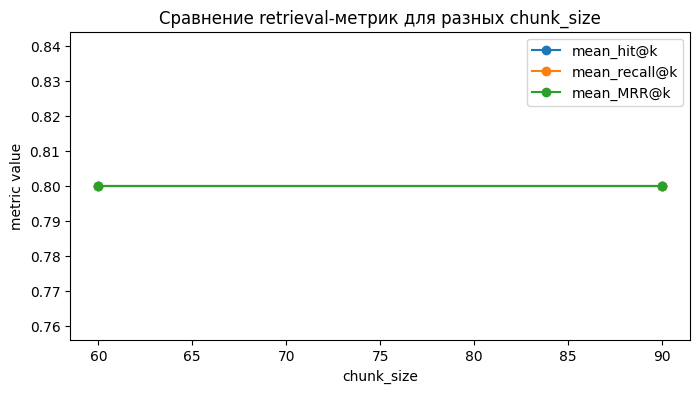

In [321]:
# Визуализируем результаты эксперимента

plt.figure(figsize=(8, 4))
plt.plot(
    experiment_summary_df["chunk_size"],
    experiment_summary_df["mean_hit@k"],
    marker="o",
    label="mean_hit@k",
)
plt.plot(
    experiment_summary_df["chunk_size"],
    experiment_summary_df["mean_recall@k"],
    marker="o",
    label="mean_recall@k",
)
plt.plot(
    experiment_summary_df["chunk_size"],
    experiment_summary_df["mean_MRR@k"],
    marker="o",
    label="mean_MRR@k",
)

plt.title("Сравнение retrieval-метрик для разных chunk_size")
plt.xlabel("chunk_size")
plt.ylabel("metric value")
plt.legend()
plt.show()

In [322]:
# Лучшая конфигурация по метрикам retrieval

best_row = experiment_summary_df.sort_values(
    by=["mean_hit@k", "mean_recall@k", "mean_MRR@k"],
    ascending=False,
).iloc[0]

print("Лучшая конфигурация:")
display(best_row.to_frame().T)

Лучшая конфигурация:


,chunk_size,overlap,num_chunks,top_k,mean_hit@k,mean_recall@k,mean_MRR@k
0,60.0,20.0,25.0,3.0,0.8,0.8,0.8


In [323]:
# Подробные результаты для каждой конфигурации

for key, value in experiment_results.items():
    print("=" * 100)
    print("Конфигурация:", key)
    display(value["results_df"])

Конфигурация: (60, 20)


,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@k,recall@k,MRR@k,first_relevant_rank
0,q_01,Почему кошки хорошо видят в сумерках?,[cat_003],"[cat_003, cat_009]",1,1.0,1.0,1.0
1,q_02,Как кошки определяют направление звука?,[cat_004],"[cat_004, cat_010, cat_001]",1,1.0,1.0,1.0
2,q_03,Зачем кошке нужны вибриссы?,[cat_005],"[cat_005, cat_002]",1,1.0,1.0,1.0
3,q_04,Почему мурлыканье не всегда означает удовольст...,[cat_006],"[cat_006, cat_009]",1,1.0,1.0,1.0
4,q_05,Почему кошки много спят и когда они наиболее а...,[cat_007],"[cat_007, cat_001, cat_003]",1,1.0,1.0,1.0
5,q_06,Как кошки маркируют территорию?,[cat_008],"[cat_010, cat_001]",0,0.0,0.0,NaN
6,q_07,"Что значит, что кошки являются облигатными хищ...",[cat_009],"[cat_007, cat_008, cat_004]",0,0.0,0.0,NaN
7,q_08,Почему мяуканье особенно важно в общении кошек...,[cat_010],"[cat_010, cat_006, cat_001]",1,1.0,1.0,1.0
8,q_09,Какие условия среды важны для благополучия дом...,[cat_012],"[cat_012, cat_008, cat_001]",1,1.0,1.0,1.0
9,q_10,Как происхождение домашней кошки связано с её ...,[cat_001],"[cat_001, cat_012, cat_002]",1,1.0,1.0,1.0


Конфигурация: (90, 20)


,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@k,recall@k,MRR@k,first_relevant_rank
0,q_01,Почему кошки хорошо видят в сумерках?,[cat_003],"[cat_003, cat_009, cat_004]",1,1.0,1.0,1.0
1,q_02,Как кошки определяют направление звука?,[cat_004],"[cat_004, cat_010, cat_006]",1,1.0,1.0,1.0
2,q_03,Зачем кошке нужны вибриссы?,[cat_005],"[cat_005, cat_002]",1,1.0,1.0,1.0
3,q_04,Почему мурлыканье не всегда означает удовольст...,[cat_006],"[cat_006, cat_009]",1,1.0,1.0,1.0
4,q_05,Почему кошки много спят и когда они наиболее а...,[cat_007],"[cat_007, cat_001, cat_003]",1,1.0,1.0,1.0
5,q_06,Как кошки маркируют территорию?,[cat_008],"[cat_010, cat_006, cat_001]",0,0.0,0.0,NaN
6,q_07,"Что значит, что кошки являются облигатными хищ...",[cat_009],"[cat_004, cat_007]",0,0.0,0.0,NaN
7,q_08,Почему мяуканье особенно важно в общении кошек...,[cat_010],"[cat_010, cat_009, cat_001]",1,1.0,1.0,1.0
8,q_09,Какие условия среды важны для благополучия дом...,[cat_012],"[cat_012, cat_001, cat_008]",1,1.0,1.0,1.0
9,q_10,Как происхождение домашней кошки связано с её ...,[cat_001],"[cat_001, cat_012, cat_002]",1,1.0,1.0,1.0


### Небольшой эксперимент с параметрами retrieval

В этом пункте был проведён один сравнительный эксперимент: сравнивались две конфигурации `chunk_size` при фиксированном `overlap = 20`.

Были рассмотрены два варианта:
- `chunk_size = 60`
- `chunk_size = 90`

Для каждой конфигурации retriever пересобирался заново:
1. документы разбивались на чанки;
2. строились векторные представления чанков;
3. создавался индекс `FAISS`;
4. выполнялась оценка retrieval на одном и том же наборе контрольных запросов.

Качество сравнивалось по метрикам:
- `hit@k`
- `recall@k`
- дополнительно `MRR@k`

Такой эксперимент позволяет понять, как размер чанка влияет на качество retrieval.

#### 2.3.7. Обновление базы знаний и переиндексация

Нужно:

- добавить в базу знаний **2-5 новых документов** или обновить часть существующих;
- повторно выполнить чанкинг / индексацию;
- показать, как retrieval меняется до и после обновления базы знаний.

Нужно привести хотя бы несколько примеров запросов, для которых видно, что обновление базы знаний действительно влияет на результат поиска.

In [324]:
# 2.3.7. Обновление базы знаний и переиндексация

new_documents = [
    {
        "doc_id": "cat_013",
        "title": "Признаки стресса у кошек",
        "text": """Стресс у кошек может проявляться по-разному: животное может прятаться, избегать контакта,
чаще вылизываться, хуже есть, проявлять повышенную настороженность или менять привычное поведение.
Причинами стресса могут быть переезд, конфликт с другими животными, нехватка ресурсов, резкие изменения
обстановки и отсутствие безопасных укрытий. Для оценки состояния важно смотреть не на один признак,
а на сочетание нескольких изменений поведения. С точки зрения благополучия снижение стресса связано
с предсказуемой средой, доступом к укрытиям и возможностью контролировать дистанцию до других животных
и людей."""
    },
    {
        "doc_id": "cat_014",
        "title": "Игровое поведение и охотничьи инстинкты кошек",
        "text": """Игра у кошек тесно связана с элементами охотничьего поведения. Во время игры кошка может
подкрадываться, резко прыгать, ловить движущийся объект и переносить его в зубах. Особенно заметно
это у котят, но и взрослые кошки часто сохраняют выраженную игровую активность. Игровое поведение
важно не только для развлечения, но и для тренировки координации, реакции и двигательных навыков.
В домашней среде игрушки частично заменяют объекты охоты, поэтому игра помогает удовлетворять
естественные поведенческие потребности кошки."""
    },
    {
        "doc_id": "cat_015",
        "title": "Почему кошки часто приземляются на лапы",
        "text": """Способность кошек разворачиваться в воздухе связана с так называемым выпрямительным рефлексом.
Во время падения кошка быстро меняет положение головы, позвоночника и конечностей, чтобы сориентировать
тело и увеличить вероятность приземления на лапы. Этому помогают гибкий позвоночник, развитая координация
и хорошее чувство положения тела в пространстве. Однако это не означает, что кошки полностью защищены
от травм при падении. Высота, поверхность приземления и состояние животного всё равно играют важную роль."""
    }
]

new_documents_df = pd.DataFrame(new_documents)
print("Число новых документов:", len(new_documents_df))
display(new_documents_df)

Число новых документов: 3


,doc_id,title,text
0,cat_013,Признаки стресса у кошек,Стресс у кошек может проявляться по-разному: ж...
1,cat_014,Игровое поведение и охотничьи инстинкты кошек,Игра у кошек тесно связана с элементами охотни...
2,cat_015,Почему кошки часто приземляются на лапы,Способность кошек разворачиваться в воздухе св...


In [325]:
# Для обновления базы знаний нам нужно объединить старые и новые документы, построить чанки для всех документов,
# построить эмбеддинги для всех чанков и заново построить индекс.

base_documents_df = documents_df[["doc_id", "title", "text"]].copy()

updated_documents_df = pd.concat(
    [base_documents_df, new_documents_df],
    ignore_index=True,
)
print("Число документов до обновления:", len(base_documents_df))
print("Число документов после обновления:", len(updated_documents_df))
display(updated_documents_df.tail())

Число документов до обновления: 12
Число документов после обновления: 15


,doc_id,title,text
10,cat_011,Почему кошки приносят добычу или игрушки,"Поведение, при котором кошка приносит добычу и..."
11,cat_012,Домашняя среда и благополучие кошки,Благополучие домашней кошки зависит не только ...
12,cat_013,Признаки стресса у кошек,Стресс у кошек может проявляться по-разному: ж...
13,cat_014,Игровое поведение и охотничьи инстинкты кошек,Игра у кошек тесно связана с элементами охотни...
14,cat_015,Почему кошки часто приземляются на лапы,Способность кошек разворачиваться в воздухе св...


In [326]:
# Строим retriever до и после обновления

retriever_chunk_size = int(best_row["chunk_size"])
retriever_overlap = int(best_row["overlap"])
top_k = 3

before_artifacts = build_retriever(
    documents_df=base_documents_df,
    chunk_size=retriever_chunk_size,
    overlap=retriever_overlap,
    device=DEVICE,
)

after_artifacts = build_retriever(
    documents_df=updated_documents_df,
    chunk_size=retriever_chunk_size,
    overlap=retriever_overlap,
    device=DEVICE,
)

print("Retriever до обновления:")
print("chunk_size =", before_artifacts.chunk_size)
print("overlap =", before_artifacts.overlap)
print("num_chunks =", len(before_artifacts.chunks_df))

print()

print("Retriever после обновления:")
print("chunk_size =", after_artifacts.chunk_size)
print("overlap =", after_artifacts.overlap)
print("num_chunks =", len(after_artifacts.chunks_df))

Используем фиксированный backend: TF-IDF fallback
Используем фиксированный backend: TF-IDF fallback
Retriever до обновления:
chunk_size = 60
overlap = 20
num_chunks = 25

Retriever после обновления:
chunk_size = 60
overlap = 20
num_chunks = 31


In [327]:
# Проверяем retrieval для новых запросов, связанных с новыми документами.

update_queries = [
    {
        "query_id": "u_01",
        "query": "Какие признаки стресса бывают у кошек?",
        "relevant_doc_ids": ["cat_013"],
    },
    {
        "query_id": "u_02",
        "query": "Как игра связана с охотничьими инстинктами кошек?",
        "relevant_doc_ids": ["cat_014"],
    },
    {
        "query_id": "u_03",
        "query": "Почему кошки часто приземляются на лапы после падения?",
        "relevant_doc_ids": ["cat_015"],
    },
]

In [328]:
# Оцениваем retrieval для новых запросов до и после обновления базы знаний.

before_results_df, before_summary_df = evaluate_benchmark(
    benchmark_queries=update_queries,
    artifacts=before_artifacts,
    top_k=top_k,
)

after_results_df, after_summary_df = evaluate_benchmark(
    benchmark_queries=update_queries,
    artifacts=after_artifacts,
    top_k=top_k,
)

print("До обновления базы знаний:")
display(before_results_df)
display(before_summary_df)

print("После обновления базы знаний:")
display(after_results_df)
display(after_summary_df)

До обновления базы знаний:


,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@k,recall@k,MRR@k,first_relevant_rank
0,u_01,Какие признаки стресса бывают у кошек?,[cat_013],"[cat_008, cat_003, cat_009]",0,0.0,0.0,None
1,u_02,Как игра связана с охотничьими инстинктами кошек?,[cat_014],"[cat_011, cat_012, cat_001]",0,0.0,0.0,None
2,u_03,Почему кошки часто приземляются на лапы после ...,[cat_015],"[cat_005, cat_010, cat_009]",0,0.0,0.0,None


,chunk_size,overlap,num_chunks,top_k,mean_hit@k,mean_recall@k,mean_MRR@k
0,60,20,25,3,0.0,0.0,0.0


После обновления базы знаний:


,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@k,recall@k,MRR@k,first_relevant_rank
0,u_01,Какие признаки стресса бывают у кошек?,[cat_013],"[cat_008, cat_013]",1,1.0,0.5,2
1,u_02,Как игра связана с охотничьими инстинктами кошек?,[cat_014],"[cat_011, cat_014]",1,1.0,0.5,2
2,u_03,Почему кошки часто приземляются на лапы после ...,[cat_015],"[cat_015, cat_014, cat_005]",1,1.0,1.0,1


,chunk_size,overlap,num_chunks,top_k,mean_hit@k,mean_recall@k,mean_MRR@k
0,60,20,31,3,1.0,1.0,0.666667


In [329]:
# Сравниваем метрики retrieval до и после обновления базы знаний.

compare_summary_df = pd.DataFrame(
    [
        {
            "stage": "before_update",
            "top_k": top_k,
            "mean_hit@k": before_summary_df.loc[0, "mean_hit@k"],
            "mean_recall@k": before_summary_df.loc[0, "mean_recall@k"],
            "mean_MRR@k": before_summary_df.loc[0, "mean_MRR@k"],
        },
        {
            "stage": "after_update",
            "top_k": top_k,
            "mean_hit@k": after_summary_df.loc[0, "mean_hit@k"],
            "mean_recall@k": after_summary_df.loc[0, "mean_recall@k"],
            "mean_MRR@k": after_summary_df.loc[0, "mean_MRR@k"],
        },
    ]
)

display(compare_summary_df)

,stage,top_k,mean_hit@k,mean_recall@k,mean_MRR@k
0,before_update,3,0.0,0.0,0.000000
1,after_update,3,1.0,1.0,0.666667


In [330]:
# Разница в метриках retrieval до и после обновления базы знаний.

delta_df = pd.DataFrame(
    [
        {
            "metric": "mean_hit@k",
            "before_update": before_summary_df.loc[0, "mean_hit@k"],
            "after_update": after_summary_df.loc[0, "mean_hit@k"],
            "delta": after_summary_df.loc[0, "mean_hit@k"] - before_summary_df.loc[0, "mean_hit@k"],
        },
        {
            "metric": "mean_recall@k",
            "before_update": before_summary_df.loc[0, "mean_recall@k"],
            "after_update": after_summary_df.loc[0, "mean_recall@k"],
            "delta": after_summary_df.loc[0, "mean_recall@k"] - before_summary_df.loc[0, "mean_recall@k"],
        },
        {
            "metric": "mean_MRR@k",
            "before_update": before_summary_df.loc[0, "mean_MRR@k"],
            "after_update": after_summary_df.loc[0, "mean_MRR@k"],
            "delta": after_summary_df.loc[0, "mean_MRR@k"] - before_summary_df.loc[0, "mean_MRR@k"],
        },
    ]
)

display(delta_df)

,metric,before_update,after_update,delta
0,mean_hit@k,0.0,1.000000,1.000000
1,mean_recall@k,0.0,1.000000,1.000000
2,mean_MRR@k,0.0,0.666667,0.666667


In [331]:
# Визуализируем сравнение retrieval для каждого запроса до и после обновления базы знаний.

for item in update_queries:
    query = item["query"]

    display(Markdown(f"## Запрос: `{query}`"))
    display(Markdown("**До обновления базы знаний**"))
    display(search_similar_chunks(query=query, artifacts=before_artifacts, top_k=top_k))
    display(Markdown("**После обновления базы знаний**"))
    display(search_similar_chunks(query=query, artifacts=after_artifacts, top_k=top_k))

## Запрос: `Какие признаки стресса бывают у кошек?`

**До обновления базы знаний**

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,cat_008,Территориальность и маркировка у кошек,cat_008_chunk_1,0.1435,другие формы маркировки. Такое поведение связа...
1,2,cat_003,Почему кошки хорошо видят в сумерках,cat_003_chunk_0,0.0591,Зрение кошек приспособлено к активности при сл...
2,3,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_1,0.0425,"определённые аминокислоты и соединения, связан..."


**После обновления базы знаний**

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,cat_008,Территориальность и маркировка у кошек,cat_008_chunk_1,0.1219,другие формы маркировки. Такое поведение связа...
1,2,cat_013,Признаки стресса у кошек,cat_013_chunk_1,0.1075,Для оценки состояния важно смотреть не на один...
2,3,cat_013,Признаки стресса у кошек,cat_013_chunk_0,0.0963,Стресс у кошек может проявляться по-разному: ж...


...

## Запрос: `Почему кошки часто приземляются на лапы после падения?`

**До обновления базы знаний**

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,cat_005,Вибриссы и пространственная ориентация,cat_005_chunk_0,0.1135,"Вибриссы, которые часто называют усами, являют..."
1,2,cat_010,Коммуникация кошек с человеком,cat_010_chunk_1,0.1063,домашние кошки адаптировали часть сигналов под...
2,3,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_1,0.0895,"определённые аминокислоты и соединения, связан..."


**После обновления базы знаний**

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,cat_015,Почему кошки часто приземляются на лапы,cat_015_chunk_0,0.1482,Способность кошек разворачиваться в воздухе св...
1,2,cat_014,Игровое поведение и охотничьи инстинкты кошек,cat_014_chunk_0,0.0739,Игра у кошек тесно связана с элементами охотни...
2,3,cat_005,Вибриссы и пространственная ориентация,cat_005_chunk_0,0.0575,"Вибриссы, которые часто называют усами, являют..."


### Обновление базы знаний и переиндексация

В этом пункте в базу знаний были добавлены новые документы по трём новым подтемам:
- признаки стресса у кошек;
- игровое поведение и охотничьи инстинкты;
- приземление кошек на лапы после падения.

После этого была собрана обновлённая база знаний, и retriever был пересобран заново:
1. документы были повторно разбиты на чанки;
2. были заново построены векторные представления;
3. был заново построен индекс `FAISS`.

Далее retrieval был оценён до и после обновления базы знаний.  
Для этого использовались специальные запросы по новым темам, чтобы было видно, как update влияет на поиск.

Сравнение показало, что после обновления базы знаний retrieval начинает находить новые релевантные документы, которые отсутствовали в исходной базе.

#### 2.3.8. Mini-RAG

Нужно собрать простой mini-RAG-конвейер:

- получить запрос пользователя;
- извлечь top-k релевантных фрагментов;
- собрать контекст из найденных фрагментов;
- сформировать ответ по найденному контексту;
- вернуть ответ вместе с источниками.

Важно:

- **не требуется** строить production-grade RAG;
- **не требуется** внешний сервис или веб-интерфейс;
- **не требуется** использовать тяжёлую LLM-инфраструктуру;
- достаточно учебного, но понятного и воспроизводимого mini-RAG.

In [332]:
# 2.3.8. Mini-RAG

rag_artifacts = after_artifacts
rag_top_k = 3

print("Mini-RAG будет использовать retriever со следующими параметрами:")
print("chunk_size =", rag_artifacts.chunk_size)
print("overlap =", rag_artifacts.overlap)
print("num_chunks =", len(rag_artifacts.chunks_df))
print("top_k =", rag_top_k)

Mini-RAG будет использовать retriever со следующими параметрами:
chunk_size = 60
overlap = 20
num_chunks = 31
top_k = 3


In [333]:
# Простое разбиение на предложения

def split_into_sentences(text: str) -> List[str]:
    text = text.replace("\n", " ").strip()
    parts = re.split(r"(?<=[.!?])\s+", text)
    sentences = [part.strip() for part in parts if part.strip()]
    return sentences

In [334]:
# Функция для выбора лучших предложений из текста.

def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if len(sentences) == 0:
        return []

    if len(sentences) <= top_n:
        return sentences

    vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray()
    query_vector = matrix[0]
    sentence_vectors = matrix[1:]
    query_norm = np.linalg.norm(query_vector)
    sentence_norms = np.linalg.norm(sentence_vectors, axis=1)

    scores = []
    for i in range(len(sentences)):
        if query_norm == 0 or sentence_norms[i] == 0:
            score = 0.0
        else:
            score = float(np.dot(query_vector, sentence_vectors[i]) / (query_norm * sentence_norms[i]))
        scores.append(score)

    ranked_idx = np.argsort(scores)[::-1][:top_n]
    best_sentences = [sentences[i] for i in ranked_idx]
    return best_sentences

In [335]:
# Функция для построения контекста из retrieval-результатов для Mini-RAG.

def build_context_from_retrieval(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Tuple[str, pd.DataFrame]:
    retrieval_df = search_similar_chunks(
        query=query,
        artifacts=artifacts,
        top_k=top_k,
    )
    context_parts = []
    for _, row in retrieval_df.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']}]\n"
            f"{row['chunk_text']}"
        )
        context_parts.append(block)

    context = "\n\n".join(context_parts)
    return context, retrieval_df

In [336]:
# Cтроим ответ по найденному контексту

def generate_answer_from_context(
    query: str,
    context: str,
    max_sentences: int = 2,
) -> str:
    context_lines = context.splitlines()

    clean_lines = []
    for line in context_lines:
        line = line.strip()
        if not line:
            continue
        if line.startswith("[Источник:"):
            continue
        clean_lines.append(line)

    clean_text = " ".join(clean_lines).strip()

    if clean_text == "":
        return "Не удалось сформировать ответ: контекст пустой."

    best_sentences = pick_best_sentences(
        query=query,
        text=clean_text,
        top_n=max_sentences,
    )

    if len(best_sentences) == 0:
        return "Не удалось сформировать ответ по найденному контексту."

    answer = " ".join(best_sentences)
    return answer

In [337]:
# Полная функция для Mini-RAG, которая выполняет retrieval и формирует ответ.

def mini_rag_answer(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict:
    context, retrieval_df = build_context_from_retrieval(
        query=query,
        artifacts=artifacts,
        top_k=top_k,
    )

    answer = generate_answer_from_context(
        query=query,
        context=context,
        max_sentences=max_answer_sentences,
    )

    sources = retrieval_df[
        ["rank", "doc_id", "title", "chunk_id", "score"]
    ].copy()

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": sources,
    }

In [338]:
# Один запрос для проверки Mini-RAG

query = "Почему кошки хорошо видят в сумерках?"
result = mini_rag_answer(
    query=query,
    artifacts=rag_artifacts,
    top_k=rag_top_k,
    max_answer_sentences=2,
)
display(Markdown(f"## Запрос\n{result['query']}"))
display(Markdown(f"## Ответ\n{result['answer']}"))
display(Markdown("## Источники"))
display(result["sources"])

## Запрос
Почему кошки хорошо видят в сумерках?

## Ответ
В сетчатке кошки много палочек — клеток, которые хорошо работают в сумерках. При этом кошки различают цвета хуже человека и видят мир менее насыщенным по оттенкам.

## Источники

,rank,doc_id,title,chunk_id,score
0,1,cat_003,Почему кошки хорошо видят в сумерках,cat_003_chunk_0,0.1065
1,2,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_1,0.0633
2,3,cat_003,Почему кошки хорошо видят в сумерках,cat_003_chunk_1,0.0601


In [339]:
# Несколько запросов для проверки Mini-RAG

mini_rag_queries = [
    "Почему кошки хорошо видят в сумерках?",
    "Зачем кошке нужны вибриссы?",
    "Почему мурлыканье не всегда означает удовольствие?",
    "Какие условия среды важны для благополучия кошки?",
    "Почему кошки часто приземляются на лапы?",
]

for query in mini_rag_queries:
    result = mini_rag_answer(
        query=query,
        artifacts=rag_artifacts,
        top_k=rag_top_k,
        max_answer_sentences=2,
    )

    display(Markdown(f"## Запрос\n{result['query']}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown("**Источники:**"))
    display(result["sources"])

## Запрос
Почему кошки хорошо видят в сумерках?

**Ответ:** В сетчатке кошки много палочек — клеток, которые хорошо работают в сумерках. При этом кошки различают цвета хуже человека и видят мир менее насыщенным по оттенкам.

**Источники:**

,rank,doc_id,title,chunk_id,score
0,1,cat_003,Почему кошки хорошо видят в сумерках,cat_003_chunk_0,0.1065
1,2,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_1,0.0633
2,3,cat_003,Почему кошки хорошо видят в сумерках,cat_003_chunk_1,0.0601


## Запрос
Зачем кошке нужны вибриссы?

...

,rank,doc_id,title,chunk_id,score
0,1,cat_012,Домашняя среда и благополучие кошки,cat_012_chunk_0,0.1632
1,2,cat_008,Территориальность и маркировка у кошек,cat_008_chunk_1,0.1199
2,3,cat_013,Признаки стресса у кошек,cat_013_chunk_1,0.0961


## Запрос
Почему кошки часто приземляются на лапы?

**Ответ:** Особенно заметно это у котят, но и взрослые кошки часто сохраняют выраженную игровую активность. Во время падения кошка быстро меняет положение головы, позвоночника и конечностей, чтобы сориентировать тело и увеличить вероятность приземления на лапы.

**Источники:**

,rank,doc_id,title,chunk_id,score
0,1,cat_015,Почему кошки часто приземляются на лапы,cat_015_chunk_0,0.1142
1,2,cat_014,Игровое поведение и охотничьи инстинкты кошек,cat_014_chunk_0,0.0811
2,3,cat_005,Вибриссы и пространственная ориентация,cat_005_chunk_0,0.0632


In [340]:
# Проверяем Mini-RAG на новом запросе, который связан с новым документом.

query = "Как игра связана с охотничьими инстинктами кошек?"
result = mini_rag_answer(
    query=query,
    artifacts=rag_artifacts,
    top_k=rag_top_k,
    max_answer_sentences=2,
)

display(Markdown(f"## Запрос\n{result['query']}"))
display(Markdown(f"## Ответ\n{result['answer']}"))
display(Markdown("## Собранный контекст"))
print(result["context"])
display(Markdown("## Источники"))
display(result["sources"])

## Запрос
Как игра связана с охотничьими инстинктами кошек?

## Ответ
Поведение, при котором кошка приносит добычу или игрушку, связано с охотничьими инстинктами и индивидуальными особенностями поведения. Домашняя среда не отменяет природных поведенческих программ, поэтому даже кошки, которые никогда не охотились на Игра у кошек тесно связана с элементами охотничьего поведения.

## Собранный контекст

[Источник: cat_011 | Почему кошки приносят добычу или игрушки | score=0.1606]
Поведение, при котором кошка приносит добычу или игрушку, связано с охотничьими инстинктами и индивидуальными особенностями поведения. У некоторых кошек это может напоминать демонстрацию добычи, у других — приглашение к взаимодействию. Такое поведение чаще наблюдается у животных с выраженной игровой активностью и интересом к движущимся объектам. Домашняя среда не отменяет природных поведенческих программ, поэтому даже кошки, которые никогда не охотились на

[Источник: cat_014 | Игровое поведение и охотничьи инстинкты кошек | score=0.0821]
Игра у кошек тесно связана с элементами охотничьего поведения. Во время игры кошка может подкрадываться, резко прыгать, ловить движущийся объект и переносить его в зубах. Особенно заметно это у котят, но и взрослые кошки часто сохраняют выраженную игровую активность. Игровое поведение важно не только для развлечения, но и для тренировки координации, реакции и двигательных на

## Источники

,rank,doc_id,title,chunk_id,score
0,1,cat_011,Почему кошки приносят добычу или игрушки,cat_011_chunk_0,0.1606
1,2,cat_014,Игровое поведение и охотничьи инстинкты кошек,cat_014_chunk_0,0.0821
2,3,cat_014,Игровое поведение и охотничьи инстинкты кошек,cat_014_chunk_1,0.0470


### Mini-RAG

В этом пункте был собран простой учебный mini-RAG-конвейер.

Его логика следующая:
1. пользователь задаёт вопрос;
2. retriever извлекает top-k наиболее релевантных чанков;
3. из найденных фрагментов собирается общий контекст;
4. по найденному контексту формируется ответ;
5. вместе с ответом возвращаются источники.

В данной работе mini-RAG реализован без тяжёлой внешней LLM-инфраструктуры.  
Ответ формируется на основе наиболее релевантных предложений из retrieved context, что делает решение воспроизводимым и достаточно понятным для учебной задачи.

#### 2.3.9. Краткий анализ ошибок

Нужно:

- показать 3-5 примеров работы mini-RAG;
- кратко прокомментировать 2-4 неудачных или пограничных случая;
- пояснить, что именно пошло не так: retrieval, состав контекста, формулировка вопроса, неполнота базы знаний и т.д.

---

In [341]:
# 2.3.9. Краткий анализ ошибок

analysis_queries = [
    "Почему кошки хорошо видят в сумерках?",
    "Зачем кошке нужны вибриссы?",
    "Как кошки ориентируются в темноте?",
    "Как кошки общаются и показывают стресс?",
    "Почему кошки любят коробки?",
]
analysis_results = []

for query in analysis_queries:
    result = mini_rag_answer(
        query=query,
        artifacts=rag_artifacts,
        top_k=rag_top_k,
        max_answer_sentences=2,
    )
    analysis_results.append(result)

    display(Markdown(f"## Запрос\n{result['query']}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown("**Источники:**"))
    display(result["sources"])

## Запрос
Почему кошки хорошо видят в сумерках?

**Ответ:** В сетчатке кошки много палочек — клеток, которые хорошо работают в сумерках. При этом кошки различают цвета хуже человека и видят мир менее насыщенным по оттенкам.

**Источники:**

,rank,doc_id,title,chunk_id,score
0,1,cat_003,Почему кошки хорошо видят в сумерках,cat_003_chunk_0,0.1065
1,2,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_1,0.0633
2,3,cat_003,Почему кошки хорошо видят в сумерках,cat_003_chunk_1,0.0601


## Запрос
Зачем кошке нужны вибриссы?

...

,rank,doc_id,title,chunk_id,score
0,1,cat_010,Коммуникация кошек с человеком,cat_010_chunk_0,0.1539
1,2,cat_001,Происхождение домашней кошки,cat_001_chunk_1,0.0700
2,3,cat_001,Происхождение домашней кошки,cat_001_chunk_0,0.0624


## Запрос
Почему кошки любят коробки?

**Ответ:** С точки зрения биологии это объясняет, почему питание кошек отличается от питания всеядных животных. Кошки известны своей гибкостью и способностью быстро менять положение тела.

**Источники:**

,rank,doc_id,title,chunk_id,score
0,1,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_1,0.1190
1,2,cat_001,Происхождение домашней кошки,cat_001_chunk_1,0.0220
2,3,cat_002,Особенности скелета и гибкости кошки,cat_002_chunk_0,0.0217


In [342]:
# Соберём краткий анализ по всем запросам в виде таблицы.

analysis_rows = []

for result in analysis_results:
    source_doc_ids = result["sources"]["doc_id"].tolist()
    analysis_rows.append(
        {
            "query": result["query"],
            "answer_preview": result["answer"][:150],
            "source_doc_ids": source_doc_ids,
        }
    )

analysis_df = pd.DataFrame(analysis_rows)
display(analysis_df)

,query,answer_preview,source_doc_ids
0,Почему кошки хорошо видят в сумерках?,"В сетчатке кошки много палочек — клеток, котор...","[cat_003, cat_009, cat_003]"
1,Зачем кошке нужны вибриссы?,Вибриссы помогают кошке оценивать расстояние д...,"[cat_005, cat_005, cat_002]"
2,Как кошки ориентируются в темноте?,темноте. Вибриссы нельзя рассматривать как обы...,"[cat_005, cat_005, cat_010]"
3,Как кошки общаются и показывают стресс?,"Кошки общаются с человеком с помощью голоса, п...","[cat_010, cat_001, cat_001]"
4,Почему кошки любят коробки?,"С точки зрения биологии это объясняет, почему ...","[cat_009, cat_001, cat_002]"


In [343]:
# На основе анализа результатов и источников для каждого запроса выделим типичные случаи ошибок и их причины.

error_cases = pd.DataFrame(
    [
        {
            "query": "Как кошки ориентируются в темноте?",
            "case_type": "пограничный",
            "what_went_wrong": "Запрос слишком широкий: для полного ответа нужны сразу несколько документов про зрение, слух и вибриссы.",
            "main_reason": "формулировка вопроса + состав контекста",
        },
        {
            "query": "Как кошки общаются и показывают стресс?",
            "case_type": "пограничный",
            "what_went_wrong": "Вопрос объединяет две разные подтемы: коммуникацию и стресс. Retrieval может вернуть только одну из них в верхних результатах.",
            "main_reason": "retrieval + состав контекста",
        },
        {
            "query": "Почему кошки любят коробки?",
            "case_type": "неудачный",
            "what_went_wrong": "В базе знаний нет отдельного документа про любовь кошек к коробкам, поэтому ответ строится по косвенно похожим источникам.",
            "main_reason": "неполнота базы знаний",
        },
    ]
)
display(error_cases)

,query,case_type,what_went_wrong,main_reason
0,Как кошки ориентируются в темноте?,пограничный,Запрос слишком широкий: для полного ответа нуж...,формулировка вопроса + состав контекста
1,Как кошки общаются и показывают стресс?,пограничный,Вопрос объединяет две разные подтемы: коммуник...,retrieval + состав контекста
2,Почему кошки любят коробки?,неудачный,В базе знаний нет отдельного документа про люб...,неполнота базы знаний


In [344]:
# Разбираем каждый слабый случай по отдельности, смотрим, какие источники были найдены и что было в контексте.

weak_queries = error_cases["query"].tolist()

for query in weak_queries:
    result = mini_rag_answer(
        query=query,
        artifacts=rag_artifacts,
        top_k=rag_top_k,
        max_answer_sentences=2,
    )

    display(Markdown(f"## Разбор слабого случая\n`{query}`"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown("**Источники:**"))
    display(result["sources"])

## Разбор слабого случая
`Как кошки ориентируются в темноте?`

**Ответ:** темноте. Вибриссы нельзя рассматривать как обычную шерсть, потому что они Кошки общаются с человеком с помощью голоса, позы тела, движения хвоста, положения ушей и зрительного контакта.

**Источники:**

,rank,doc_id,title,chunk_id,score
0,1,cat_005,Вибриссы и пространственная ориентация,cat_005_chunk_1,0.1061
1,2,cat_005,Вибриссы и пространственная ориентация,cat_005_chunk_0,0.1038
2,3,cat_010,Коммуникация кошек с человеком,cat_010_chunk_0,0.0949


## Разбор слабого случая
`Как кошки общаются и показывают стресс?`

...

,rank,doc_id,title,chunk_id,score
0,1,cat_010,Коммуникация кошек с человеком,cat_010_chunk_0,0.1539
1,2,cat_001,Происхождение домашней кошки,cat_001_chunk_1,0.0700
2,3,cat_001,Происхождение домашней кошки,cat_001_chunk_0,0.0624


## Разбор слабого случая
`Почему кошки любят коробки?`

**Ответ:** С точки зрения биологии это объясняет, почему питание кошек отличается от питания всеядных животных. Кошки известны своей гибкостью и способностью быстро менять положение тела.

**Источники:**

,rank,doc_id,title,chunk_id,score
0,1,cat_009,Питание кошек как облигатных хищников,cat_009_chunk_1,0.1190
1,2,cat_001,Происхождение домашней кошки,cat_001_chunk_1,0.0220
2,3,cat_002,Особенности скелета и гибкости кошки,cat_002_chunk_0,0.0217


### Краткий анализ ошибок

Для анализа работы mini-RAG были рассмотрены несколько примерных запросов.  
Часть из них дала хорошие ответы, но также были выделены пограничные и неудачные случаи.

Основные причины ошибок или ограничений оказались следующими:
1. **слишком широкая формулировка вопроса** — для ответа требуется информация сразу из нескольких документов;
2. **неполный состав retrieval-контекста** — в top-k попадает только часть нужных источников;
3. **объединение нескольких подтем в одном вопросе** — retrieval может вернуть документы только по одной из них;
4. **неполнота базы знаний** — если нужной темы нет в документах, mini-RAG не может построить полноценный ответ.

Таким образом, качество mini-RAG зависит не только от генерации ответа, но и от качества retrieval, состава контекста и полноты базы знаний.

## 3. Эксперименты

### 3.1. Обязательная часть

Нужно выполнить **один** основной учебный pipeline:

- фиксированная база знаний;
- фиксированный способ чанкинга;
- фиксированная embedding-модель;
- один retrieval-конвейер с `FAISS`;
- один набор контрольных запросов;
- одна оценка retrieval;
- одно обновление базы знаний;
- один mini-RAG-конвейер.

Главное:

- воспроизводимость;
- корректный retrieval;
- понятная оценка качества;
- демонстрация влияния обновления базы знаний.

### 3.2. Что не требуется

В обязательной части **не требуется**:

- `pgvector`;
- внешняя векторная БД;
- веб-приложение;
- сравнение 3-4 embedding-моделей;
- большой подбор гиперпараметров;
- LangChain или другие тяжёлые фреймворки;
- сложный reranking;
- production-grade реализация RAG.

---

## 4. Артефакты (обязательно)

В папке `homeworks/HW14/artifacts/` должны быть:

1. `retrieval_eval.csv` – таблица с результатами retrieval на контрольных запросах.

   Минимальные поля:

   - `query`
   - `expected_source`
   - `retrieved_sources`
   - `hit_at_k`

   Дополнительно приветствуется поле:

   - `rank_of_first_relevant`

2. `rag_examples.csv` – таблица с примерами работы mini-RAG.

   Минимальные поля:

   - `question`
   - `answer`
   - `retrieved_sources`

3. `retrieval_before_after_update.csv` – сравнение retrieval до и после обновления базы знаний.

   Минимальные поля:

   - `query`
   - `before_retrieved_sources`
   - `after_retrieved_sources`
   - `changed`

Этого достаточно.

Дополнительно приветствуется, но не обязательно:

- `chunk_examples.csv`
- `retrieval_metrics_summary.json`
- `retrieval_quality_plot.png`

---

In [345]:
# 2.3.10. Сохранение артефактов

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

print("Папка для артефактов:", artifacts_dir.resolve())

Папка для артефактов: C:\Users\kuzal\projects\Git_rep\allure-aie-lab\homeworks\HW14\artifacts


In [346]:
# Сохраняем результаты оценки retrieval в виде CSV-файла для удобного просмотра и анализа.

retrieval_eval_df = benchmark_results_df.copy()
retrieval_eval_df["expected_source"] = retrieval_eval_df["relevant_doc_ids"].apply(
    lambda x: ", ".join(x)
)
retrieval_eval_df["retrieved_sources"] = retrieval_eval_df["predicted_doc_ids"].apply(
    lambda x: ", ".join(x)
)
retrieval_eval_df["hit_at_k"] = retrieval_eval_df["hit@k"]
retrieval_eval_df["rank_of_first_relevant"] = retrieval_eval_df["first_relevant_rank"]
retrieval_eval_df = retrieval_eval_df[
    ["query", "expected_source", "retrieved_sources", "hit_at_k", "rank_of_first_relevant"]
].copy()
retrieval_eval_path = artifacts_dir / "retrieval_eval.csv"
retrieval_eval_df.to_csv(retrieval_eval_path, index=False, encoding="utf-8-sig")

print("Сохранён файл:", retrieval_eval_path)
display(retrieval_eval_df.head())

Сохранён файл: artifacts\retrieval_eval.csv


,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,Почему кошки хорошо видят в сумерках?,cat_003,"cat_003, cat_009, cat_004",1,1.0
1,Как кошки определяют направление звука?,cat_004,"cat_004, cat_010, cat_011",1,1.0
2,Зачем кошке нужны вибриссы?,cat_005,"cat_005, cat_002",1,1.0
3,Почему мурлыканье не всегда означает удовольст...,cat_006,"cat_006, cat_009",1,1.0
4,Почему кошки много спят и когда они наиболее а...,cat_007,"cat_007, cat_001, cat_003",1,1.0


In [347]:
# Сохраняем примеры работы Mini-RAG для нескольких запросов в виде CSV-файла.

rag_questions = [
    "Почему кошки хорошо видят в сумерках?",
    "Зачем кошке нужны вибриссы?",
    "Почему мурлыканье не всегда означает удовольствие?",
    "Какие условия среды важны для благополучия кошки?",
    "Почему кошки часто приземляются на лапы?",
]
rag_rows = []
for question in rag_questions:
    result = mini_rag_answer(
        query=question,
        artifacts=rag_artifacts,
        top_k=rag_top_k,
        max_answer_sentences=2,
    )
    retrieved_sources = result["sources"]["doc_id"].astype(str).tolist()
    rag_rows.append(
        {
            "question": question,
            "answer": result["answer"],
            "retrieved_sources": ", ".join(retrieved_sources),
        }
    )

rag_examples_df = pd.DataFrame(rag_rows)

rag_examples_path = artifacts_dir / "rag_examples.csv"
rag_examples_df.to_csv(rag_examples_path, index=False, encoding="utf-8-sig")

print("Сохранён файл:", rag_examples_path)
display(rag_examples_df)

Сохранён файл: artifacts\rag_examples.csv


,question,answer,retrieved_sources
0,Почему кошки хорошо видят в сумерках?,"В сетчатке кошки много палочек — клеток, котор...","cat_003, cat_009, cat_003"
1,Зачем кошке нужны вибриссы?,Вибриссы помогают кошке оценивать расстояние д...,"cat_005, cat_005, cat_002"
2,Почему мурлыканье не всегда означает удовольст...,Поэтому мурлыканье не всегда означает только у...,"cat_006, cat_006, cat_009"
3,Какие условия среды важны для благополучия кошки?,Изучение территориальности важно для понимания...,"cat_012, cat_008, cat_013"
4,Почему кошки часто приземляются на лапы?,"Особенно заметно это у котят, но и взрослые ко...","cat_015, cat_014, cat_005"


In [348]:
# Сравниваем retrieval для новых запросов до и после обновления базы знаний, сохраняем результаты в виде CSV-файла.

before_after_rows = []

for item in update_queries:
    query = item["query"]

    before_df = search_similar_chunks(
        query=query,
        artifacts=before_artifacts,
        top_k=top_k,
    )

    after_df = search_similar_chunks(
        query=query,
        artifacts=after_artifacts,
        top_k=top_k,
    )
    before_sources = before_df["doc_id"].astype(str).tolist()
    after_sources = after_df["doc_id"].astype(str).tolist()

    before_sources_str = ", ".join(before_sources)
    after_sources_str = ", ".join(after_sources)
    before_after_rows.append(
        {
            "query": query,
            "before_retrieved_sources": before_sources_str,
            "after_retrieved_sources": after_sources_str,
            "changed": before_sources_str != after_sources_str,
        }
    )
retrieval_before_after_df = pd.DataFrame(before_after_rows)
retrieval_before_after_path = artifacts_dir / "retrieval_before_after_update.csv"
retrieval_before_after_df.to_csv(
    retrieval_before_after_path,
    index=False,
    encoding="utf-8-sig",
)

print("Сохранён файл:", retrieval_before_after_path)
display(retrieval_before_after_df)

Сохранён файл: artifacts\retrieval_before_after_update.csv


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Какие признаки стресса бывают у кошек?,"cat_008, cat_003, cat_009","cat_008, cat_013, cat_013",True
1,Как игра связана с охотничьими инстинктами кошек?,"cat_011, cat_012, cat_001","cat_011, cat_014, cat_014",True
2,Почему кошки часто приземляются на лапы после ...,"cat_005, cat_010, cat_009","cat_015, cat_014, cat_005",True


In [349]:
# Сохраняем примеры чанков из базы знаний в виде CSV-файла для удобного просмотра и анализа.

chunk_examples_df = chunks_df.head(10).copy()
chunk_examples_path = artifacts_dir / "chunk_examples.csv"
chunk_examples_df.to_csv(chunk_examples_path, index=False, encoding="utf-8-sig")

print("Сохранён файл:", chunk_examples_path)

Сохранён файл: artifacts\chunk_examples.csv


In [350]:
packages = [
    "faiss",
    "sentence_transformers",
    "transformers",
    "sklearn",
    "torch",
]
for name in packages:
    try:
        module = importlib.import_module(name)
        version = getattr(module, "__version__", "version attribute not found")
        print(f"{name}: {version}")
    except Exception as e:
        print(f"{name}: not installed ({e})")

faiss: 1.13.2
sentence_transformers: 5.4.0
transformers: 5.5.0
sklearn: 1.8.0
torch: 2.10.0+cpu


## 5. Отчёт `report.md` (обязательно)

1. В материалах семинара будет шаблон: `S14-hw-report-template.md`.
2. Нужно создать файл `homeworks/HW14/report.md` и заполнить его по шаблону.

Важно:

- не менять названия разделов (заголовков) в отчёте;
- вставлять результаты и выводы в соответствующие секции;
- в отчёте должны быть ссылки на файлы из `artifacts/`.

---

## 6. Требования к структуре и именованию (итог)

К дедлайну в репозитории должно быть:

- `homeworks/HW14/HW14.ipynb`
- `homeworks/HW14/report.md`
- `homeworks/HW14/artifacts/`
  - `retrieval_eval.csv`
  - `rag_examples.csv`
  - `retrieval_before_after_update.csv`

Требования:

- названия папок и файлов – строго как указано;
- ноутбук выполняется без ошибок при последовательном запуске всех ячеек;
- в ноутбуке есть база знаний, чанкинг, эмбеддинги, индекс `FAISS`, оценка retrieval, обновление базы знаний и mini-RAG;
- отчёт заполнен по шаблону.

---

## 7. Критерии зачёта

HW14 считается зачтённым, если:

1. Соблюдена структура `homeworks/HW14/` и нейминг файлов.
2. В `HW14.ipynb` есть:

   - загрузка выбранной базы знаний;
   - краткий sanity-check документов;
   - чанкинг и показ примеров чанков;
   - построение векторных представлений;
   - индекс `FAISS` и поиск по нескольким запросам;
   - набор контрольных запросов для retrieval;
   - расчёт минимум `hit@k` и `recall@k`;
   - один небольшой сравнительный эксперимент по параметрам retrieval;
   - обновление базы знаний и переиндексация;
   - mini-RAG с ответами по найденному контексту;
   - возврат источников вместе с ответом;
   - краткий анализ нескольких ошибок или ограничений.

3. В `artifacts/` лежат требуемые файлы: `retrieval_eval.csv`, `rag_examples.csv`, `retrieval_before_after_update.csv`.
4. Заполнен `report.md` по шаблону.

---

## 8. Опциональная часть (для желающих)

Не обязательна для зачёта, но приветствуется:

- сравнение двух embedding-моделей;
- дополнительная retrieval-метрика (`MRR@k` и др.);
- reranking;
- более подробный анализ ошибок на 8-12 примерах;
- сравнение двух способов сборки контекста для mini-RAG;
- использование компактной генеративной модели вместо простого шаблонного генератора ответа.

---

## 9. Сроки и порядок сдачи

- Работа выполняется индивидуально.
- Дедлайн объявляется преподавателем отдельно.
- Факт сдачи: к дедлайну в репозитории есть `homeworks/HW14/` со всеми файлами и корректно выполненным ноутбуком.